In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [23]:
shuffel_idx = np.random.permutation(len(np.load('exp_data/gradients/wz binning test/train_x.npz')['all_grads']))
def get_binning_test_data(start,stop,step,file_name):
    print(f'{start}')
    _grad_data = []
    for i in range(2):
        for j in range(start,stop,step):
            print(f'Loading worker {1} epoch {i} batch {j}')
            with np.load(f'exp_data/gradients/worker_{1}/grads_epoch_{i}_batch_{j}.npz') as data:
                g = [data[layer].astype(np.float16).flatten()
                     for layer in data.files[::2][:]]
                _grad_data.append(g)
    all_grads=[np.concatenate(gg) for gg in zip(*_grad_data)]
    all_grads=np.concatenate(all_grads)
    
    all_grads=all_grads[shuffel_idx]
    np.savez_compressed(f'exp_data/gradients/wz binning test/{file_name}', all_grads=all_grads)
    return all_grads

# train_x=get_binning_test_data(0, 40+0, 4, 'train_x.npz')
# test_x=get_binning_test_data( 1, 40+1, 4, 'test_x.npz')
# train_y=get_binning_test_data(2, 40+2, 4, 'train_y.npz')
# test_y=get_binning_test_data( 3, 40+3, 4, 'test_y.npz')

0
Loading worker 1 epoch 0 batch 0
Loading worker 1 epoch 0 batch 4
Loading worker 1 epoch 0 batch 8
Loading worker 1 epoch 0 batch 12
Loading worker 1 epoch 0 batch 16
Loading worker 1 epoch 0 batch 20
Loading worker 1 epoch 0 batch 24
Loading worker 1 epoch 0 batch 28
Loading worker 1 epoch 0 batch 32
Loading worker 1 epoch 0 batch 36
Loading worker 1 epoch 1 batch 0
Loading worker 1 epoch 1 batch 4
Loading worker 1 epoch 1 batch 8
Loading worker 1 epoch 1 batch 12
Loading worker 1 epoch 1 batch 16
Loading worker 1 epoch 1 batch 20
Loading worker 1 epoch 1 batch 24
Loading worker 1 epoch 1 batch 28
Loading worker 1 epoch 1 batch 32
Loading worker 1 epoch 1 batch 36
1
Loading worker 1 epoch 0 batch 1
Loading worker 1 epoch 0 batch 5
Loading worker 1 epoch 0 batch 9
Loading worker 1 epoch 0 batch 13
Loading worker 1 epoch 0 batch 17
Loading worker 1 epoch 0 batch 21
Loading worker 1 epoch 0 batch 25
Loading worker 1 epoch 0 batch 29
Loading worker 1 epoch 0 batch 33
Loading worker 1 ep

In [24]:
_train_x = np.load('exp_data/gradients/wz binning test/train_x.npz')['all_grads']
_test_x = np.load('exp_data/gradients/wz binning test/test_x.npz')['all_grads']
_train_y = np.load('exp_data/gradients/wz binning test/train_y.npz')['all_grads']
_test_y = np.load('exp_data/gradients/wz binning test/test_y.npz')['all_grads']

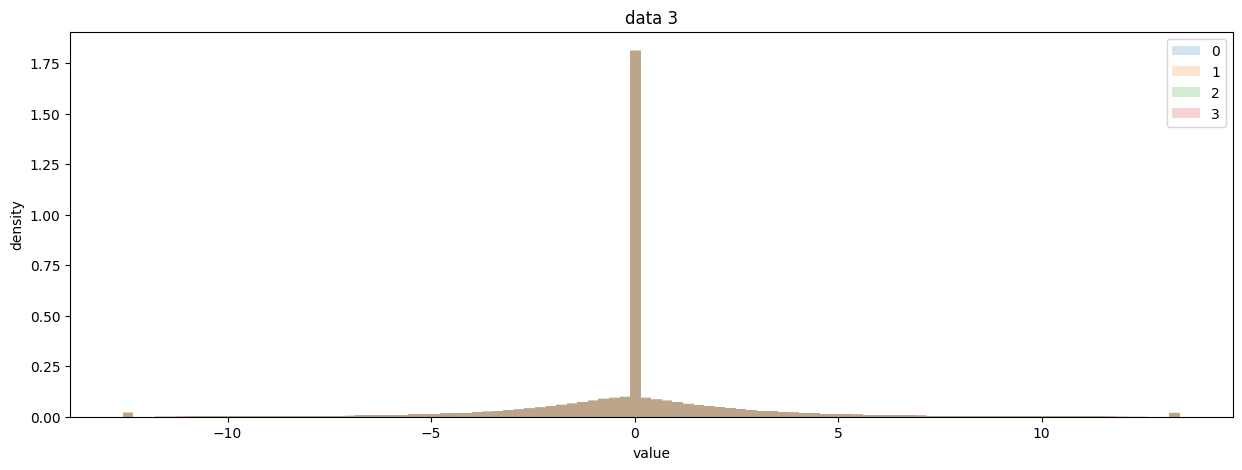

min: -12.5703,   1%: -9.4297,   5%: -2.5879,   50%: 0.0000,   95%: 2.5332,   99%: 9.9062,   max: 13.3906
min: -12.5703,   1%: -9.5312,   5%: -2.4883,   50%: 0.0000,   95%: 2.5586,   99%: 10.4453,   max: 13.3906
min: -12.5703,   1%: -8.5859,   5%: -2.4844,   50%: 0.0000,   95%: 2.3574,   99%: 9.0625,   max: 13.3906
min: -12.5703,   1%: -8.9766,   5%: -2.5000,   50%: 0.0000,   95%: 2.5059,   99%: 9.3828,   max: 13.3906


In [25]:
temp=np.array([_train_x, _test_x, _train_y, _test_y])*(2/0.0003)
train_x, test_x, train_y, test_y=np.clip(temp, *np.percentile(temp, [0.5,99.5]))

train_x = np.expand_dims(train_x, axis=1)
test_x = np.expand_dims(test_x, axis=1)
train_y = np.expand_dims(train_y, axis=1)
test_y = np.expand_dims(test_y, axis=1)

plt.figure(figsize=(15, 5))
for i, data in enumerate([train_x, test_x, train_y, test_y]):
    plt.hist(data, bins=100, density=True, alpha=0.2, label=f'{i}')
    plt.title(f"data {i}")
    plt.xlabel("value")
    plt.ylabel("density")
plt.legend()
plt.show()

for a in [train_x, test_x, train_y, test_y]:
    temp=np.percentile(a, [1,10,50,90,99])
    print(f"min: {a.min():.4f},   1%: {temp[0]:.4f},   5%: {temp[1]:.4f},   "
          f"50%: {temp[2]:.4f},   95%: {temp[3]:.4f},   99%: {temp[4]:.4f},   max: {a.max():.4f}")

In [40]:
import torch
torch.set_float32_matmul_precision('high')

import numpy as np
from pytorch_lightning import Trainer

from importlib import reload
import quantizer.wz_quant_ANN
reload(quantizer.wz_quant_ANN)

from quantizer.wz_quant_ANN import PL_EncoderDecoder_ANN

rtrain_x, rtest_x, rtrain_y, rtest_y=[torch.tensor(l).to(torch.float32) 
                    for l in [train_x, test_x, train_y, test_y]]

# si_std, noise_power=0.1, 0.01,
# side_info = torch.empty([50000, 1]).normal_(mean=0, std=si_std)
# data_x = side_info + torch.empty_like(side_info).normal_(mean=0, std=np.sqrt(noise_power))
# rtrain_x, rtest_x, rtrain_y, rtest_y = (
#     data_x[2000:], data_x[:2000], side_info[2000:], side_info[:2000])


In [55]:
b_s, code_size =  10000, 5
temp=torch.utils.data.TensorDataset(rtest_x, rtest_y)
test_dataloader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(temp, range(0, len(temp), 1000)),
    batch_size=b_s, shuffle=False, num_workers=3, persistent_workers=True)

temp=torch.utils.data.TensorDataset(rtrain_x, rtrain_y)
train_dataloader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(temp, range(0, len(temp), 100)),
    batch_size=b_s, shuffle=True, num_workers=5, persistent_workers=True)

coding_model = PL_EncoderDecoder_ANN(lr=2e-4,bit_count=code_size,)

In [56]:
trainer = Trainer(
    accelerator="gpu",
    max_epochs=15,
    log_every_n_steps=len(test_dataloader)//2,
    enable_progress_bar=True,
    enable_model_summary=False,
)

trainer.fit(coding_model, train_dataloaders=train_dataloader, val_dataloaders=test_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


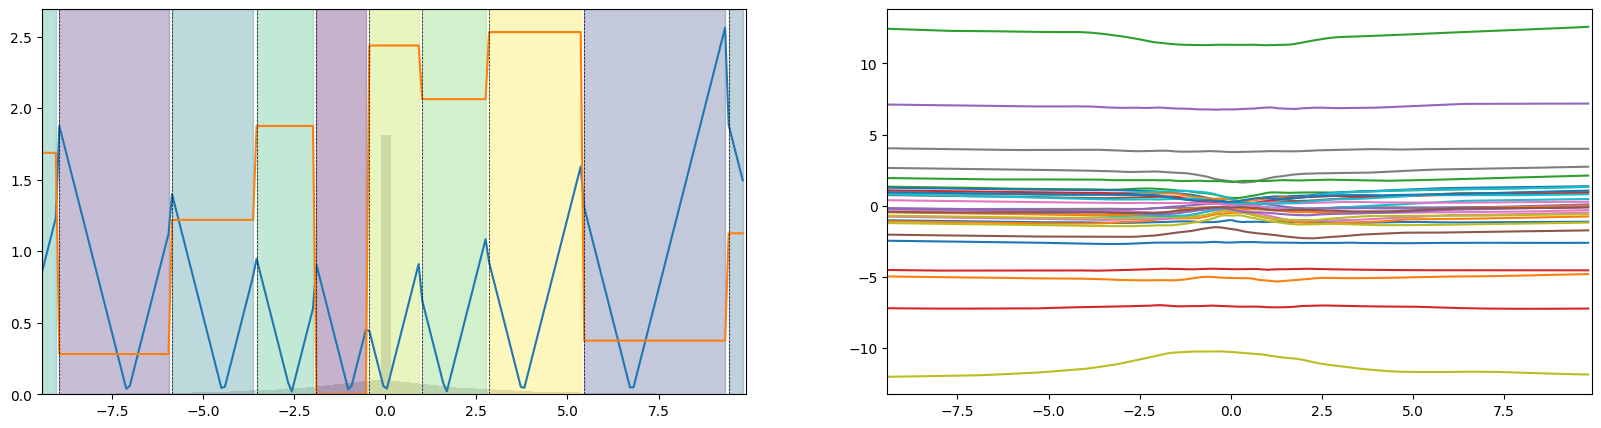

In [64]:
from matplotlib import pyplot as plt
import torch.nn.functional as F

coding_model.to('cuda').eval()

# min_v, max_v = rtrain_x.min().numpy(), rtrain_x.max().numpy()
min_v, max_v = np.percentile(rtrain_x.cpu().numpy(), [1, 99])

fig, ax = plt.subplots(nrows=1, ncols=2)
fig.set_size_inches(20, 5)

x_step =((max_v-min_v)/200)
x= torch.tensor(np.arange(min_v, max_v, x_step))
x=x.to(torch.float32).to('cuda').unsqueeze(1)
y= torch.zeros_like(x).to('cuda')
with torch.no_grad():
    reconstruct, soft_code, prior = coding_model.forward(x, y)
    bin = soft_code.argmax(dim=1)

bin = bin.detach().cpu().numpy()
x = x.detach().cpu().numpy()
ax[0].hist(rtrain_x.numpy()[:len(rtrain_x)//5],
           bins=100, alpha=0.3, color='gray', label='data histogram', density=True)
ax[0].plot(x, abs(x-reconstruct.cpu().numpy()))
ax[0].plot(x, bin/2**code_size*3)

# Seeing the binning with colors
unique_v = np.unique(bin)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_v)))
for i, val in enumerate(unique_v):
    mask = (bin == val)
    ax[0].axvline(x[mask][0], color='black', linestyle='--', linewidth=0.5)
    temp = [x[mask][0,0], x[mask][0,0]]
    for j in range(1, len(x[mask])):
        # if the next point of same color is far enough
        if temp[1] + x_step*1.1 < x[mask][j][0]:
            ax[0].axvspan(*temp, color=colors[i], alpha=0.3)
            temp[0] = x[mask][j][0]
        temp[1] = x[mask][j][0]
    # Ensure the last span is added
    ax[0].axvspan(*temp, color=colors[i], alpha=0.3)
ax[0].set_xlim(min_v, max_v)

# __________________________________________________________
# Seeing the reconstruction points
with torch.no_grad():
    for i in range(2**code_size):
        y=torch.tensor(np.arange(min_v, max_v, x_step))
        y=y.to(torch.float32).to('cuda').unsqueeze(1)
        codes = F.one_hot(
            torch.ones([y.shape[0]], dtype=torch.long, device='cuda')*i,
            num_classes=2**code_size).float()
        reconstruct = coding_model.coding_model.decoder(codes, y)

        ax[1].plot(y.detach().cpu().numpy(),
                   reconstruct.detach().cpu().numpy(),
                   label='bin={}'.format(i))
ax[1].set_xlim(min_v, max_v)

plt.show()
